# Exercise 5

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load in dataset
data = np.loadtxt('3class_data.csv', delimiter=',')
x = data[:-1,:]  # shape (N,P)
y = data[-1,:].astype(int)  # labels 0,1,2
N, P = x.shape
C = int(np.max(y)) + 1

In [4]:
# compute C linear combinations of input point, one per classifier
def model(x, w):
    a = w[0,:][:,None] + np.dot(w[1:,:].T, x)
    return a

lam = 1e-5
def multiclass_perceptron(w):
    all_evals = model(x, w)  # (C,P)
    a = np.max(all_evals, axis=0)
    b = all_evals[y, np.arange(P)]
    cost = np.sum(a - b)
    cost = cost + lam*np.linalg.norm(w[1:,:],'fro')**2
    return cost/float(P)

In [5]:
def grad_multiclass_perceptron(w):
    scores = model(x, w)  # (C,P)
    max_idx = np.argmax(scores, axis=0)
    mis = max_idx != y

    G = np.zeros((C, P))
    idx = np.where(mis)[0]
    if idx.size > 0:
        G[max_idx[idx], idx] = 1
        G[y[idx], idx] -= 1

    xhat = np.vstack([np.ones((1, P)), x])
    grad = xhat @ G.T
    grad[1:,:] += 2*lam*w[1:,:]
    return grad/float(P)

def gradient_descent(g, grad_g, w, alpha, max_its):
    weight_history = [w.copy()]
    cost_history = [g(w)]
    for k in range(max_its):
        grad = grad_g(w)
        w = w - alpha*grad
        weight_history.append(w.copy())
        cost_history.append(g(w))
    return weight_history, cost_history

In [7]:
# Exercise 5.1: fit multiclass perceptron
max_its = 1000
w = 0.1*np.random.randn(N+1, C)
weight_history, cost_history = gradient_descent(multiclass_perceptron, grad_multiclass_perceptron, w, 0.1, max_its)

plt.figure(figsize=(6,4))
plt.plot(cost_history)
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('Multiclass Perceptron Cost')
plt.tight_layout()
plt.savefig('multiclass_perceptron_cost.png')
plt.clf()

<Figure size 600x400 with 0 Axes>

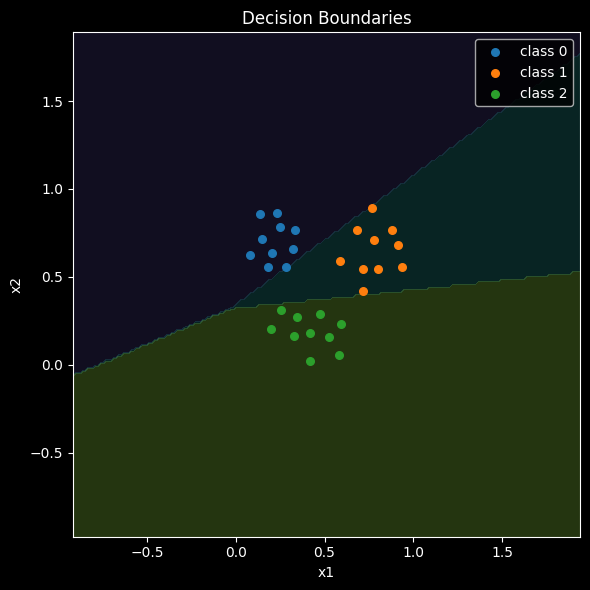

In [6]:
# Exercise 5.2: plot data with decision boundaries
def plot_decision_boundaries(w):
    x_min, x_max = x[0,:].min() - 1.0, x[0,:].max() + 1.0
    y_min, y_max = x[1,:].min() - 1.0, x[1,:].max() + 1.0
    xs = np.linspace(x_min, x_max, 200)
    ys = np.linspace(y_min, y_max, 200)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.vstack([xx.ravel(), yy.ravel()])
    scores = model(grid, w)
    preds = np.argmax(scores, axis=0)
    zz = preds.reshape(xx.shape)

    plt.figure(figsize=(6,6))
    plt.contourf(xx, yy, zz, alpha=0.25, levels=np.arange(C+1)-0.5, cmap='viridis')
    colors = ['tab:blue','tab:orange','tab:green']
    for c in range(C):
        idx = (y == c)
        plt.scatter(x[0,idx], x[1,idx], s=30, color=colors[c], label=f'class {c}')
    plt.legend()
    plt.title('Decision Boundaries')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.tight_layout()

w_best = weight_history[-1]
plot_decision_boundaries(w_best)